# Comparison: Original vs New PyFLEXTRKR cell tracking (WRF 500m, d3, 2018-11-29)

Compare cloudid output between:
- **Original** (`d3/`): `dilate_method=orig`, `expand_method=orig`, `echotop_method=orig` (default ndimage convolution)
- **New** (`d3_pyflex26.4_test/`): `dilate_method=edt`, `expand_method=edt`, `echotop_method=fast`, `convolve_method=fft`

Config used: `config_lasso_wrf500m_20181129_gefs09_base.yml`

Variables compared:
- `echotop10`, `echotop20`, `echotop30` — echo-top heights (m)
- `conv_mask`, `conv_mask_inflated` — labeled convective cell masks
- `convsf` — Steiner conv/strat classification (0–4)
- `refl_bkg` — Steiner background reflectivity (dBZ)
- `peakedness` — reflectivity peakedness above background (dB)

For each variable, 2D maps are shown at the **worst time for that specific variable**
(the timestamp with the largest aggregate difference).

In [1]:
import glob
import os
import warnings
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import xarray as xr
import yaml

# ── Paths ────────────────────────────────────────────────────────────────────
DIR_ORIG = Path(
    "/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs09/base/d3/tracking"
)
DIR_NEW = Path(
    "/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/20181129/gefs09/base/d3_pyflex26.4_test/tracking"
)
# 3-D reflectivity source files (for profile plots)
DIR_3D = Path(
    "/gpfs/wolf2/arm/atm131/proj-shared/money/20181129/gefs09/base/les/subset_d3"
)

CONFIG_FILE = Path(
    "/ccsopen/home/zhe1feng1/program/lasso/cellgrowth/tracking/slurm/config_lasso_wrf500m_20181129_gefs09_base.yml"
)

# ── Parameters ───────────────────────────────────────────────────────────────
ECHOTOP_LARGE_DIFF_M = 500.0   # threshold for 'large' echotop difference
N_PROFILES = 6                  # number of reflectivity profile examples to show
REFL_VARNAME = "REFL_10CM"      # 3-D reflectivity variable in source files
HEIGHT_VARNAME = "HAMSL"        # height-above-MSL coordinate in source files

print(f"DIR_ORIG exists: {DIR_ORIG.exists()}")
print(f"DIR_NEW  exists: {DIR_NEW.exists()}")
print(f"DIR_3D   exists: {DIR_3D.exists()}")
print(f"CONFIG_FILE exists: {CONFIG_FILE.exists()}")

DIR_ORIG exists: True
DIR_NEW  exists: True
DIR_3D   exists: True
CONFIG_FILE exists: True


In [2]:
# Read configuration from yaml file
stream = open(CONFIG_FILE, "r")
config = yaml.full_load(stream)
geolimits = config.get("geolimits", None)
x_coordname = config.get("x_coordname", "XLONG")
y_coordname = config.get("y_coordname", "XLAT")
print(f"geolimits: {geolimits}")

# Get lat/lon limits
buffer = 0
latmin, latmax = geolimits[0]-buffer, geolimits[2]+buffer
lonmin, lonmax = geolimits[1]-buffer, geolimits[3]+buffer

geolimits: [-33.3, -65.9, -30.8, -63.4]


## 1  File scan — find matched cloudid pairs

In [3]:
orig_files = {f.name: f for f in sorted(DIR_ORIG.glob("cloudid_*.nc"))}
new_files  = {f.name: f for f in sorted(DIR_NEW.glob("cloudid_*.nc"))}

common_names = sorted(set(orig_files) & set(new_files))
print(f"Files in orig : {len(orig_files)}")
print(f"Files in new  : {len(new_files)}")
print(f"Matched pairs : {len(common_names)}")
if common_names:
    print(f"  First: {common_names[0]}")
    print(f"  Last : {common_names[-1]}")

Files in orig : 144
Files in new  : 144
Matched pairs : 144
  First: cloudid_20181129_120500.nc
  Last : cloudid_20181130_000000.nc


## 2  Bulk load — collect 2-D arrays for every variable

In [4]:
VARS_ECHOTOP  = ["echotop10", "echotop20", "echotop30"]
VARS_MASK     = ["conv_mask", "conv_mask_inflated"]
VARS_SCALAR   = ["refl_bkg", "peakedness"]
VARS_CLASS    = ["convsf"]
ALL_VARS      = VARS_ECHOTOP + VARS_MASK + VARS_CLASS + VARS_SCALAR

data = {v: {"orig": [], "new": []} for v in ALL_VARS}
timestamps = []
lat2d = lon2d = None

for fname in common_names:
    ds_o = xr.open_dataset(orig_files[fname])
    ds_n = xr.open_dataset(new_files[fname])

    if lat2d is None:
        lat2d = ds_o["latitude"].values
        lon2d = ds_o["longitude"].values

    ts = pd.Timestamp(ds_o["time"].values[0])
    timestamps.append(ts)

    for v in ALL_VARS:
        try:
            data[v]["orig"].append(ds_o[v].values.squeeze())
        except KeyError:
            data[v]["orig"].append(None)
        try:
            data[v]["new"].append(ds_n[v].values.squeeze())
        except KeyError:
            data[v]["new"].append(None)

    ds_o.close()
    ds_n.close()

timestamps = np.array(timestamps)
print(f"Loaded {len(timestamps)} time steps")
print(f"Grid shape: {lat2d.shape}")

Loaded 144 time steps
Grid shape: (554, 475)


## 3  Summary statistics

In [5]:
rows = []

for v in ALL_VARS:
    orig_list = data[v]["orig"]
    new_list  = data[v]["new"]

    # Skip if variable not present in one of the runs
    valid_pairs = [(o, n) for o, n in zip(orig_list, new_list)
                   if o is not None and n is not None]
    if not valid_pairs:
        rows.append({"variable": v, "note": "not present in one/both runs"})
        continue

    o_all = np.concatenate([a.ravel() for a, _ in valid_pairs])
    n_all = np.concatenate([a.ravel() for _, a in valid_pairs])

    if v in VARS_ECHOTOP + VARS_SCALAR:
        # continuous: ignore NaN
        valid = np.isfinite(o_all) & np.isfinite(n_all)
        diff  = n_all[valid] - o_all[valid]
        row = dict(
            variable=v,
            n_valid=int(valid.sum()),
            bias=float(np.mean(diff)),
            MAE=float(np.mean(np.abs(diff))),
            RMSE=float(np.sqrt(np.mean(diff**2))),
            max_abs_diff=float(np.max(np.abs(diff))),
        )
        if v in VARS_ECHOTOP:
            row["pct_large_diff"] = 100.0 * float(np.mean(np.abs(diff) > ECHOTOP_LARGE_DIFF_M))
    elif v in VARS_MASK:
        # both are labeled; compare binary coverage (>0)
        o_bin = (o_all > 0).astype(np.int8)
        n_bin = (n_all > 0).astype(np.int8)
        pct_agree = 100.0 * float(np.mean(o_bin == n_bin))
        row = dict(variable=v, pct_pixel_agree=pct_agree)
    elif v in VARS_CLASS:
        # categorical
        pct_agree = 100.0 * float(np.mean(o_all == n_all))
        row = dict(variable=v, pct_exact_agree=pct_agree)
    else:
        row = dict(variable=v)

    rows.append(row)

df_stats = pd.DataFrame(rows).set_index("variable")
pd.set_option("display.float_format", "{:.4f}".format)
print("\n=== Summary statistics (all files) ===")
display(df_stats)


=== Summary statistics (all files) ===


,n_valid,bias,MAE,RMSE,max_abs_diff,pct_large_diff,pct_pixel_agree,pct_exact_agree
variable,,,,,,,,
echotop10,6480429.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN
echotop20,3767594.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN
echotop30,2078379.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN
conv_mask,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NaN
conv_mask_inflated,NaN,NaN,NaN,NaN,NaN,NaN,100.0000,NaN
convsf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0000
refl_bkg,37893600.0000,-0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN
peakedness,37893600.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN


## 4  echotop10 time series — per-timestamp max|diff| and large-diff pixel count

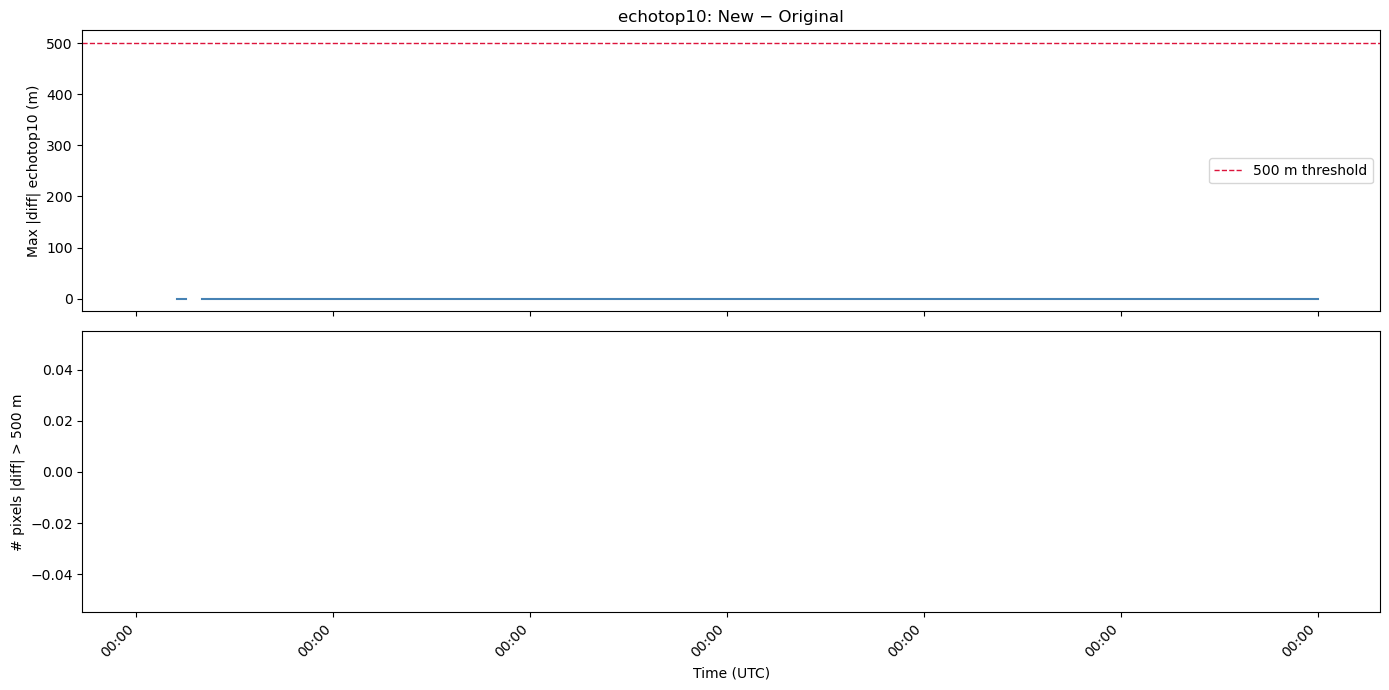

In [6]:
et10_max_diff   = []
et10_nlarge     = []

for o, n in zip(data["echotop10"]["orig"], data["echotop10"]["new"]):
    if o is None or n is None:
        et10_max_diff.append(np.nan)
        et10_nlarge.append(0)
        continue
    valid = np.isfinite(o) & np.isfinite(n)
    d = np.abs(n - o)
    et10_max_diff.append(float(np.nanmax(d)) if valid.any() else np.nan)
    et10_nlarge.append(int(np.sum(d[valid] > ECHOTOP_LARGE_DIFF_M)))

et10_max_diff = np.array(et10_max_diff)
et10_nlarge   = np.array(et10_nlarge)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(timestamps, et10_max_diff, lw=1.5, color="steelblue")
axes[0].axhline(ECHOTOP_LARGE_DIFF_M, color="crimson", lw=1, ls="--",
                label=f"{ECHOTOP_LARGE_DIFF_M:.0f} m threshold")
axes[0].set_ylabel("Max |diff| echotop10 (m)")
axes[0].legend()
axes[0].set_title("echotop10: New − Original")

axes[1].bar(timestamps, et10_nlarge, width=pd.Timedelta("4min"), color="darkorange",
            align="center")
axes[1].set_ylabel(f"# pixels |diff| > {ECHOTOP_LARGE_DIFF_M:.0f} m")
axes[1].set_xlabel("Time (UTC)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: pd.Timestamp(x, unit='ns').strftime("%H:%M")))

fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

## 5  echotop10 large-diff pixels — top-N table

In [7]:
large_diff_records = []

for ti, (ts, o, n) in enumerate(zip(timestamps,
                                     data["echotop10"]["orig"],
                                     data["echotop10"]["new"])):
    if o is None or n is None:
        continue
    valid = np.isfinite(o) & np.isfinite(n)
    d = np.abs(n - o)
    idx = np.argwhere(valid & (d > ECHOTOP_LARGE_DIFF_M))
    for jj, ii in idx:
        large_diff_records.append(dict(
            timestamp=ts,
            ti=ti, j=int(jj), i=int(ii),
            diff_m=float(d[jj, ii]),
            orig_m=float(o[jj, ii]),
            new_m=float(n[jj, ii]),
            lat=float(lat2d[jj, ii]),
            lon=float(lon2d[jj, ii]),
        ))

df_large = (
    pd.DataFrame(large_diff_records)
    .sort_values("diff_m", ascending=False)
    .reset_index(drop=True)
)
print(f"Total pixels with |echotop10 diff| > {ECHOTOP_LARGE_DIFF_M:.0f} m: "
      f"{len(df_large)} across {len(timestamps)} files")
display(df_large.head(20))

KeyError: 'diff_m'

## 6  Reflectivity profiles at largest echotop10 differences

In [8]:
def _cldhamsl_path(ts):
    """Return the path to the cldhamsl 3-D source file for a given timestamp."""
    dtstr = ts.strftime("%Y%m%d.%H%M%S")
    stem = f"corlasso_cldhamsl_2018112900gefs09d3_base_M1.m1.{dtstr}.nc"
    return DIR_3D / stem


top_cases = df_large.head(N_PROFILES) if len(df_large) >= N_PROFILES else df_large

if top_cases.empty:
    print(f"No pixels with |echotop10 diff| > {ECHOTOP_LARGE_DIFF_M:.0f} m — skipping profile plots.")
else:
    ncols = min(3, len(top_cases))
    nrows = int(np.ceil(len(top_cases) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.array(axes).ravel()

    for ax_idx, (_, row) in enumerate(top_cases.iterrows()):
        ax = axes[ax_idx]
        ts = row["timestamp"]
        jj, ii = int(row["j"]), int(row["i"])

        src_path = _cldhamsl_path(ts)
        if not src_path.exists():
            ax.text(0.5, 0.5, f"Source file\nnot found:\n{src_path.name}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8)
            ax.set_title(f"{ts.strftime('%H:%M')} ({jj},{ii})", fontsize=9)
            continue

        ds3 = xr.open_dataset(src_path)
        try:
            # Squeeze time dimension; shape is (nz, ny, nx)
            refl3d = ds3[REFL_VARNAME].values.squeeze()
            height = ds3[HEIGHT_VARNAME].values.squeeze()
            grid_lat = ds3[y_coordname].values.squeeze()
            grid_lon = ds3[x_coordname].values.squeeze()
            # height may be 3-D (nz, ny, nx) or 1-D (nz)
            if height.ndim == 3:
                height_prof = height[:, jj, ii]
            elif height.ndim == 2:
                height_prof = height[:, 0]  # fallback
            else:
                height_prof = height
            # Subset domain
            # For 2D coordinates, create mask and find bounding box
            mask = ((grid_lon >= lonmin) & (grid_lon <= lonmax) & \
                    (grid_lat >= latmin) & (grid_lat <= latmax)).squeeze()
            # Get y/x indices limits from the mask
            y_idx, x_idx = np.where(mask == True)
            xmin, xmax = np.min(x_idx), np.max(x_idx)
            ymin, ymax = np.min(y_idx), np.max(y_idx)
            # Subset the reflectivity to the bounding box
            refl3d = refl3d[:, ymin:ymax+1, xmin:xmax+1]
            refl_prof = refl3d[:, jj, ii]

            ax.plot(refl_prof, height_prof / 1e3, lw=1.5, color="navy", label="Reflectivity")
            ax.axhline(row["orig_m"] / 1e3, color="blue", lw=1.5, ls="--",
                       label=f"Orig {row['orig_m']/1e3:.2f} km")
            ax.axhline(row["new_m"]  / 1e3, color="red",  lw=1.5, ls="-.",
                       label=f"New  {row['new_m']/1e3:.2f} km")
            ax.set_xlabel("Reflectivity (dBZ)", fontsize=8)
            ax.set_ylabel("Height AGL (km)", fontsize=8)
            ax.set_title(
                f"{ts.strftime('%H:%M')} | pixel ({jj},{ii})\n"
                f"lat={row['lat']:.3f} lon={row['lon']:.3f}\n"
                f"|diff|={row['diff_m']:.0f} m",
                fontsize=8,
            )
            ax.legend(fontsize=7)
            ax.set_xlim(-10, 70)
        except Exception as exc:
            ax.text(0.5, 0.5, f"Error:\n{exc}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=7)
        finally:
            ds3.close()

    # Hide unused axes
    for ax in axes[len(top_cases):]:
        ax.set_visible(False)

    plt.suptitle(
        f"Reflectivity profiles at top-{len(top_cases)} echotop10 differences",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

NameError: name 'df_large' is not defined

In [ ]:
# # _file3d = Path(f"{DIR_3D}/corlasso_cldhamsl_2018112900gefs09d3_base_M1.m1.20181130.000000.nc")
# # _file3d.exists()
# # jj, ii = 329, 102

# _file3d = Path(f"{DIR_3D}/corlasso_cldhamsl_2018112900gefs09d3_base_M1.m1.20181129.205500.nc")
# _file3d.exists()
# jj, ii = 182, 336

In [10]:
# ds3 = xr.open_dataset(_file3d)

# # Squeeze time dimension; shape is (nz, ny, nx)
# refl3d = ds3[REFL_VARNAME].values.squeeze()
# height = ds3[HEIGHT_VARNAME].values.squeeze()
# grid_lat = ds3[y_coordname].values.squeeze()
# grid_lon = ds3[x_coordname].values.squeeze()
# # height may be 3-D (nz, ny, nx) or 1-D (nz)
# if height.ndim == 3:
#     height_prof = height[:, jj, ii]
# elif height.ndim == 2:
#     height_prof = height[:, 0]  # fallback
# else:
#     height_prof = height
# # Subset domain
# # For 2D coordinates, create mask and find bounding box
# mask = ((grid_lon >= lonmin) & (grid_lon <= lonmax) & \
#         (grid_lat >= latmin) & (grid_lat <= latmax)).squeeze()
# # Get y/x indices limits from the mask
# y_idx, x_idx = np.where(mask == True)
# xmin, xmax = np.min(x_idx), np.max(x_idx)
# ymin, ymax = np.min(y_idx), np.max(y_idx)
# # Subset the reflectivity to the bounding box
# refl3d = refl3d[:, ymin:ymax+1, xmin:xmax+1]
# refl_prof = refl3d[:, jj, ii]

# plt.plot(refl_prof, height_prof / 1e3, 'o-', lw=1.5, color="navy")

## 7  Helper functions for 2-D map plots

In [11]:
def _worst_time_continuous(varname, metric="max_abs_diff"):
    """Return the index of the timestamp with the largest max|diff| for a continuous variable."""
    scores = []
    for o, n in zip(data[varname]["orig"], data[varname]["new"]):
        if o is None or n is None:
            scores.append(-np.inf)
            continue
        valid = np.isfinite(o) & np.isfinite(n)
        d = np.abs(n.astype(float) - o.astype(float))
        scores.append(float(np.nanmax(d)) if valid.any() else -np.inf)
    return int(np.argmax(scores))


def _worst_time_binary(varname):
    """Return the index of the timestamp with the most binary-disagreement pixels."""
    scores = []
    for o, n in zip(data[varname]["orig"], data[varname]["new"]):
        if o is None or n is None:
            scores.append(-1)
            continue
        scores.append(int(np.sum((o > 0) != (n > 0))))
    return int(np.argmax(scores))


def _worst_time_categorical(varname):
    """Return the index of the timestamp with the most categorical mismatches."""
    scores = []
    for o, n in zip(data[varname]["orig"], data[varname]["new"]):
        if o is None or n is None:
            scores.append(-1)
            continue
        scores.append(int(np.sum(o != n)))
    return int(np.argmax(scores))


def _worst_time_echotop(varname):
    """Return the index with the most pixels exceeding ECHOTOP_LARGE_DIFF_M."""
    scores = []
    for o, n in zip(data[varname]["orig"], data[varname]["new"]):
        if o is None or n is None:
            scores.append(-1)
            continue
        valid = np.isfinite(o) & np.isfinite(n)
        d = np.abs(n - o)
        scores.append(int(np.sum(valid & (d > ECHOTOP_LARGE_DIFF_M))))
    return int(np.argmax(scores))


def _plot_3panel_continuous(varname, ti, cmap="turbo", units="",
                             vmin=None, vmax=None, diff_vmax=None):
    """
    Plot orig | new | diff for a continuous variable at time index ti.
    Uses turbo for orig/new panels and RdBu_r for the diff panel.
    """
    o = data[varname]["orig"][ti]
    n = data[varname]["new"][ti]
    if o is None or n is None:
        print(f"{varname}: data not available at ti={ti}")
        return
    diff = n.astype(float) - o.astype(float)

    if vmin is None:
        valid = np.isfinite(o)
        vmin = float(np.nanpercentile(o[valid], 2)) if valid.any() else 0.0
    if vmax is None:
        valid = np.isfinite(o)
        vmax = float(np.nanpercentile(o[valid], 98)) if valid.any() else 1.0
    if diff_vmax is None:
        diff_vmax = float(np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 99)) or 1.0

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    ts_str = timestamps[ti].strftime("%Y-%m-%d %H:%M UTC")

    im0 = axes[0].pcolormesh(lon2d, lat2d, o, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    axes[0].set_title(f"Original — {ts_str}")
    plt.colorbar(im0, ax=axes[0], label=f"{varname} {units}")

    im1 = axes[1].pcolormesh(lon2d, lat2d, n, cmap=cmap, vmin=vmin, vmax=vmax, shading="auto")
    axes[1].set_title(f"New — {ts_str}")
    plt.colorbar(im1, ax=axes[1], label=f"{varname} {units}")

    norm_diff = mcolors.TwoSlopeNorm(vmin=-diff_vmax, vcenter=0, vmax=diff_vmax)
    im2 = axes[2].pcolormesh(lon2d, lat2d, diff, cmap="RdBu_r", norm=norm_diff, shading="auto")
    axes[2].set_title(f"New − Original — {ts_str}")
    plt.colorbar(im2, ax=axes[2], label=f"Δ{varname} {units}")

    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    plt.suptitle(f"{varname}  (worst time for this variable)", fontsize=11)
    plt.tight_layout()
    plt.show()


def _plot_3panel_labeled(varname, ti):
    """
    Plot orig | new | diff for a labeled cell mask (0 = bg, 1..N = cells).
    Orig and new use a qualitative colormap with white background.
    Diff shows binary coverage: (new>0) - (orig>0) in {-1, 0, +1}.
    """
    o = data[varname]["orig"][ti]
    n = data[varname]["new"][ti]
    if o is None or n is None:
        print(f"{varname}: data not available at ti={ti}")
        return
    diff_bin = (n > 0).astype(np.int8) - (o > 0).astype(np.int8)

    # Colormap for labeled arrays: white for 0, tab20 for labels 1..N
    n_labels = max(int(o.max()), int(n.max()), 1)
    tab20    = plt.cm.tab20(np.linspace(0, 1, 20))
    colors   = np.vstack([[1, 1, 1, 1], np.tile(tab20, (n_labels // 20 + 1, 1))[:n_labels]])
    cmap_labeled = mcolors.ListedColormap(colors)
    bounds   = np.arange(-0.5, n_labels + 1.5)
    norm_lab = mcolors.BoundaryNorm(bounds, cmap_labeled.N)

    # Diff: -1 (only in orig), 0 (agree), +1 (only in new)
    cmap_diff = mcolors.ListedColormap(["blue", "white", "red"])
    norm_diff = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap_diff.N)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    ts_str = timestamps[ti].strftime("%Y-%m-%d %H:%M UTC")

    axes[0].pcolormesh(lon2d, lat2d, o, cmap=cmap_labeled, norm=norm_lab, shading="auto")
    axes[0].set_title(f"Original — {ts_str}")

    axes[1].pcolormesh(lon2d, lat2d, n, cmap=cmap_labeled, norm=norm_lab, shading="auto")
    axes[1].set_title(f"New — {ts_str}")

    im2 = axes[2].pcolormesh(lon2d, lat2d, diff_bin, cmap=cmap_diff, norm=norm_diff, shading="auto")
    cb2 = plt.colorbar(im2, ax=axes[2], ticks=[-1, 0, 1])
    cb2.set_ticklabels(["Orig only", "Agree", "New only"])
    axes[2].set_title(f"Coverage diff — {ts_str}")

    n_orig_only = int(np.sum(diff_bin == -1))
    n_new_only  = int(np.sum(diff_bin ==  1))
    n_agree_on  = int(np.sum((o > 0) & (n > 0)))
    axes[2].text(0.01, 0.99,
                 f"Orig-only: {n_orig_only}\nNew-only:  {n_new_only}\nBoth>0:    {n_agree_on}",
                 transform=axes[2].transAxes, va="top", fontsize=8,
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    plt.suptitle(f"{varname}  (worst time: max binary disagreement)", fontsize=11)
    plt.tight_layout()
    plt.show()


def _plot_3panel_categorical(varname, ti, n_cats=5):
    """
    Plot orig | new | diff for a categorical integer variable (e.g. convsf 0-4).
    Orig/new use a discrete colormap; diff uses a diverging colormap.
    """
    o = data[varname]["orig"][ti]
    n = data[varname]["new"][ti]
    if o is None or n is None:
        print(f"{varname}: data not available at ti={ti}")
        return
    diff = n.astype(np.int16) - o.astype(np.int16)

    # convsf: 0=NaN/missing, 1=no_surf_echo, 2=weak_echo, 3=strat, 4=conv
    cat_colors = ["white", "#a8ddb5", "#2b8cbe", "#fed976", "#d7301f"]
    cmap_cat   = mcolors.ListedColormap(cat_colors[:n_cats])
    bounds_cat = np.arange(-0.5, n_cats + 0.5)
    norm_cat   = mcolors.BoundaryNorm(bounds_cat, cmap_cat.N)

    vdiff = max(abs(int(diff.min())), abs(int(diff.max())), 1)
    norm_diff = mcolors.TwoSlopeNorm(vmin=-vdiff, vcenter=0, vmax=vdiff)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    ts_str = timestamps[ti].strftime("%Y-%m-%d %H:%M UTC")

    im0 = axes[0].pcolormesh(lon2d, lat2d, o, cmap=cmap_cat, norm=norm_cat, shading="auto")
    cb0 = plt.colorbar(im0, ax=axes[0], ticks=range(n_cats))
    cb0.set_ticklabels(["0:missing", "1:no_echo", "2:weak", "3:strat", "4:conv"][:n_cats])
    axes[0].set_title(f"Original — {ts_str}")

    im1 = axes[1].pcolormesh(lon2d, lat2d, n, cmap=cmap_cat, norm=norm_cat, shading="auto")
    cb1 = plt.colorbar(im1, ax=axes[1], ticks=range(n_cats))
    cb1.set_ticklabels(["0:missing", "1:no_echo", "2:weak", "3:strat", "4:conv"][:n_cats])
    axes[1].set_title(f"New — {ts_str}")

    im2 = axes[2].pcolormesh(lon2d, lat2d, diff, cmap="RdBu_r", norm=norm_diff, shading="auto")
    plt.colorbar(im2, ax=axes[2], label="New − Orig (category)")
    axes[2].set_title(f"Difference — {ts_str}")

    for ax in axes:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    plt.suptitle(f"{varname}  (worst time: max categorical mismatch)", fontsize=11)
    plt.tight_layout()
    plt.show()

## 8  2-D maps: echotop10, echotop20, echotop30


echotop10  worst time: 2018-11-29 12:05:00  (ti=0)


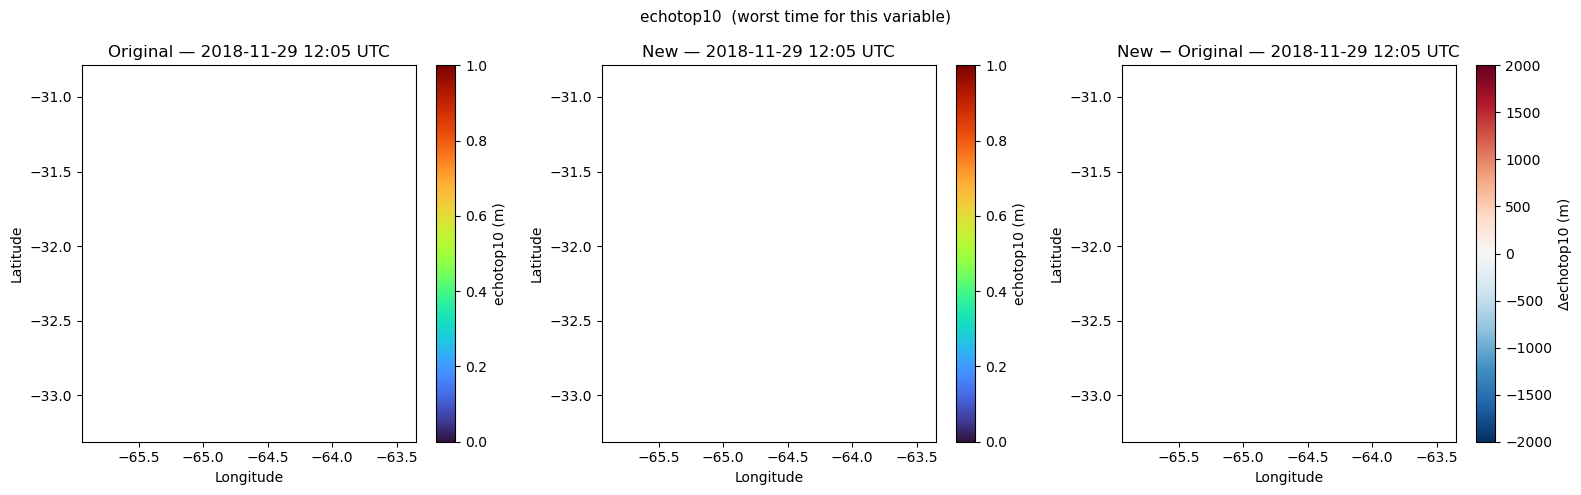


echotop20  worst time: 2018-11-29 12:05:00  (ti=0)


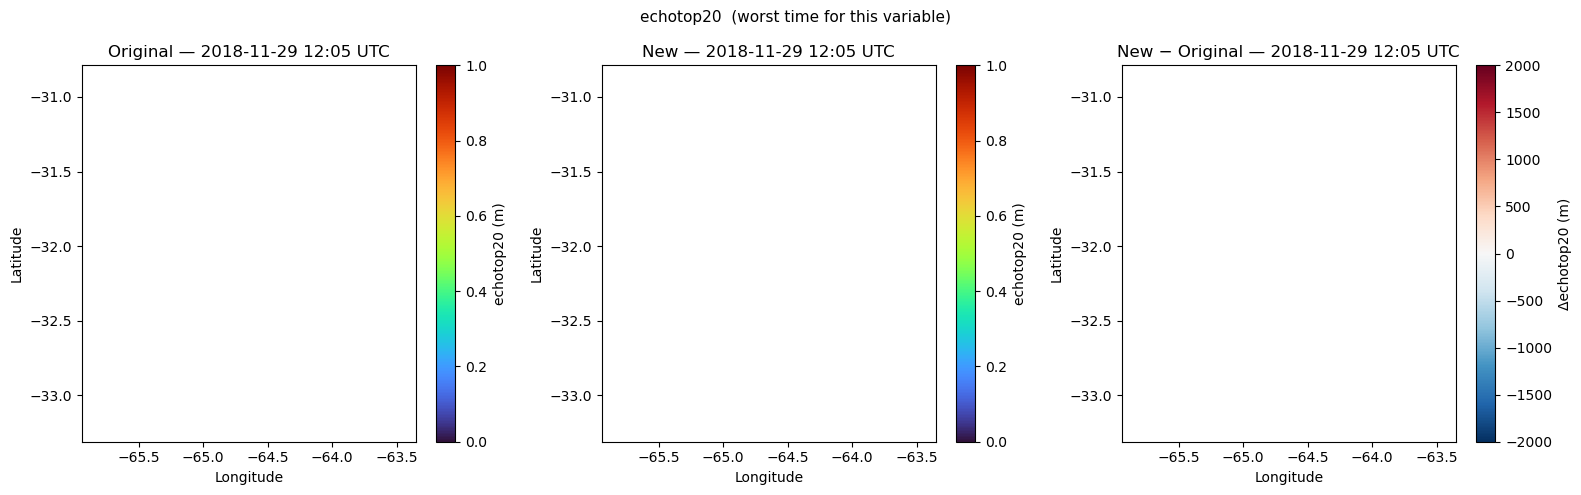


echotop30  worst time: 2018-11-29 12:05:00  (ti=0)


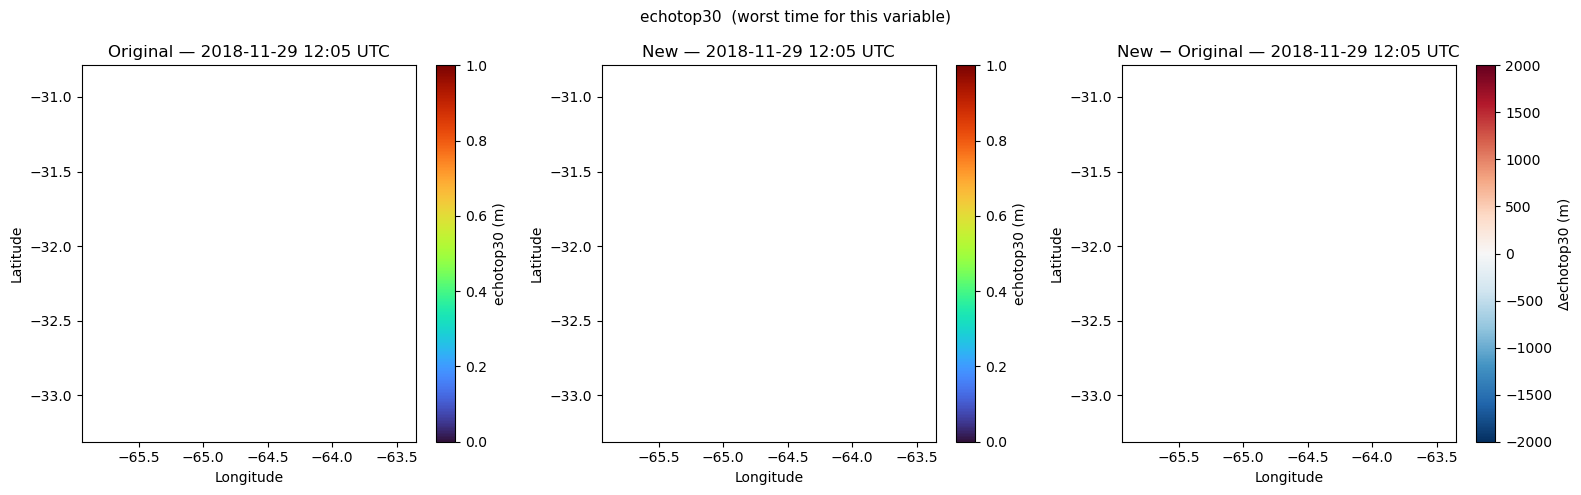

In [12]:
for vname in VARS_ECHOTOP:
    ti = _worst_time_echotop(vname)
    print(f"\n{vname}  worst time: {timestamps[ti]}  (ti={ti})")
    _plot_3panel_continuous(
        vname, ti,
        cmap="turbo",
        units="(m)",
        diff_vmax=2000.0,
    )

## 9  2-D maps: conv_mask and conv_mask_inflated


conv_mask  worst time: 2018-11-29 12:05:00  (ti=0)


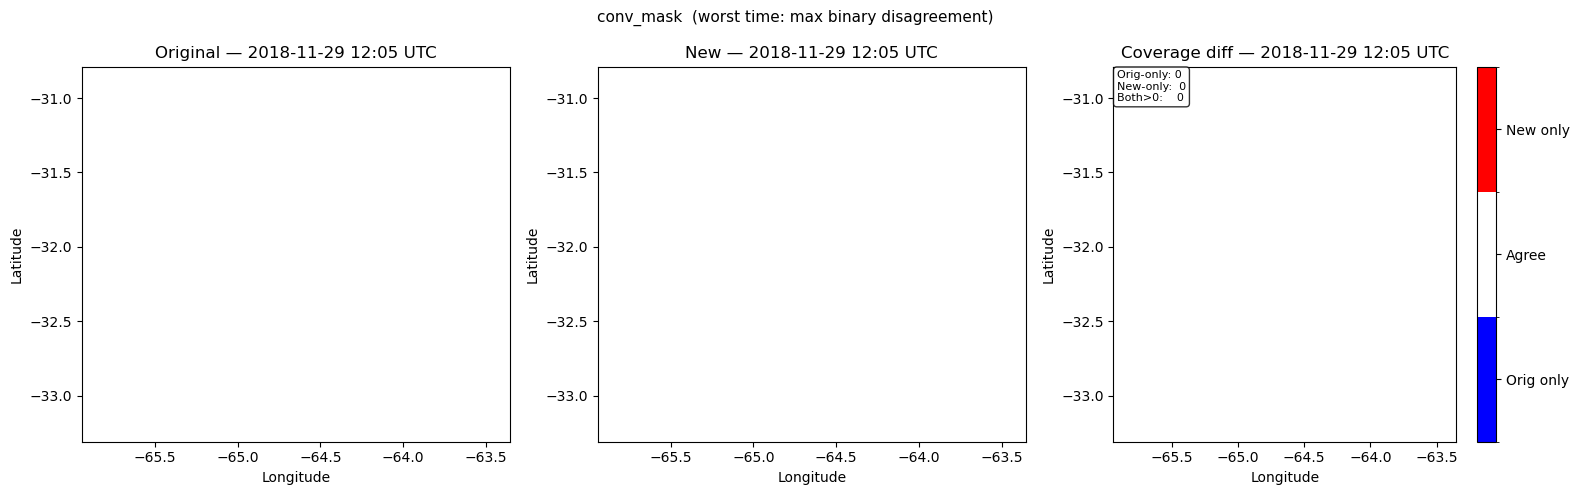


conv_mask_inflated  worst time: 2018-11-29 12:05:00  (ti=0)


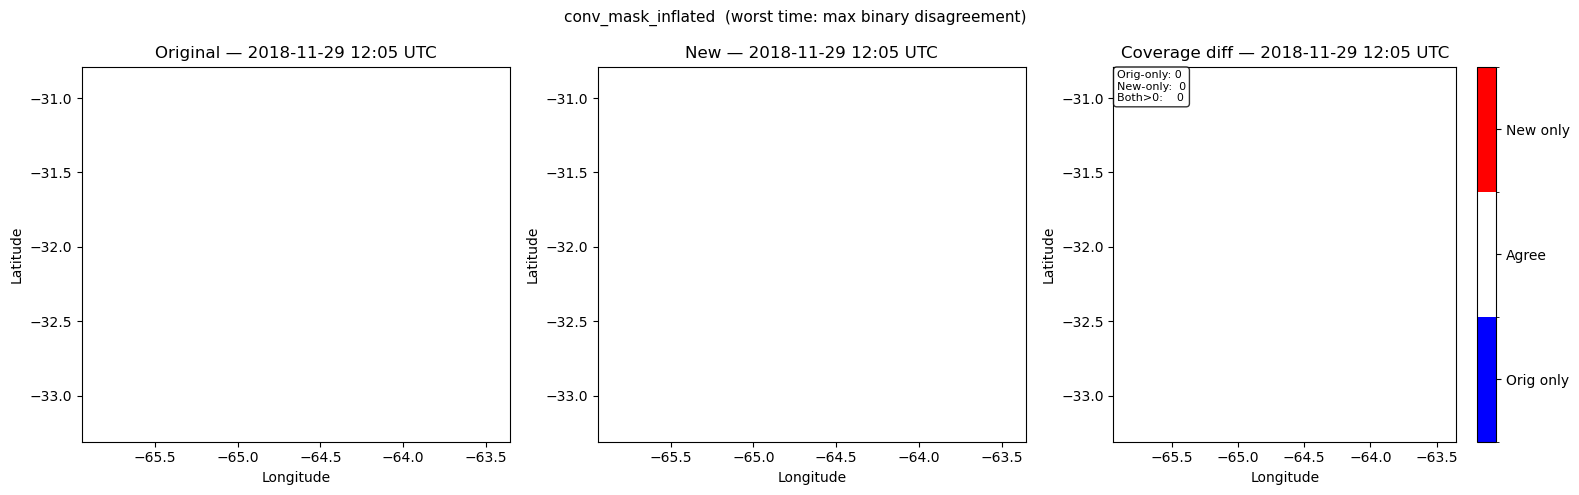

In [13]:
for vname in VARS_MASK:
    ti = _worst_time_binary(vname)
    print(f"\n{vname}  worst time: {timestamps[ti]}  (ti={ti})")
    _plot_3panel_labeled(vname, ti)

## 10  2-D maps: convsf (Steiner classification)

convsf  worst time: 2018-11-29 12:05:00  (ti=0)


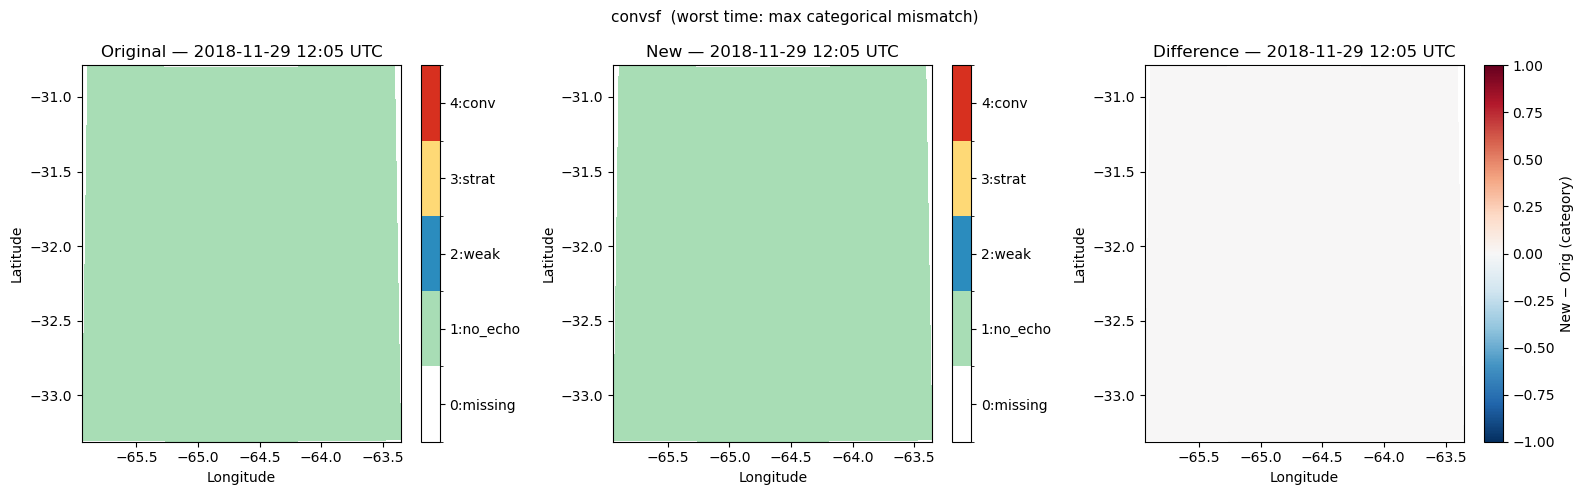

In [14]:
ti = _worst_time_categorical("convsf")
print(f"convsf  worst time: {timestamps[ti]}  (ti={ti})")
_plot_3panel_categorical("convsf", ti)

## 11  2-D maps: refl_bkg and peakedness


refl_bkg  worst time: 2018-11-29 22:25:00  (ti=124)


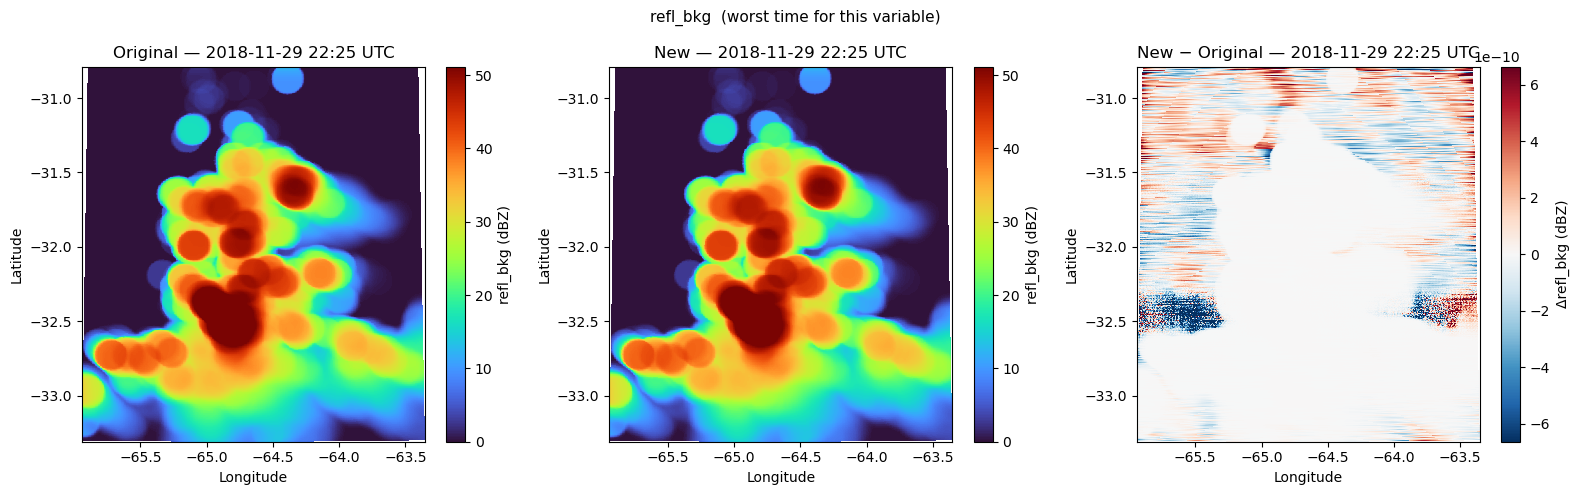


peakedness  worst time: 2018-11-29 19:40:00  (ti=91)


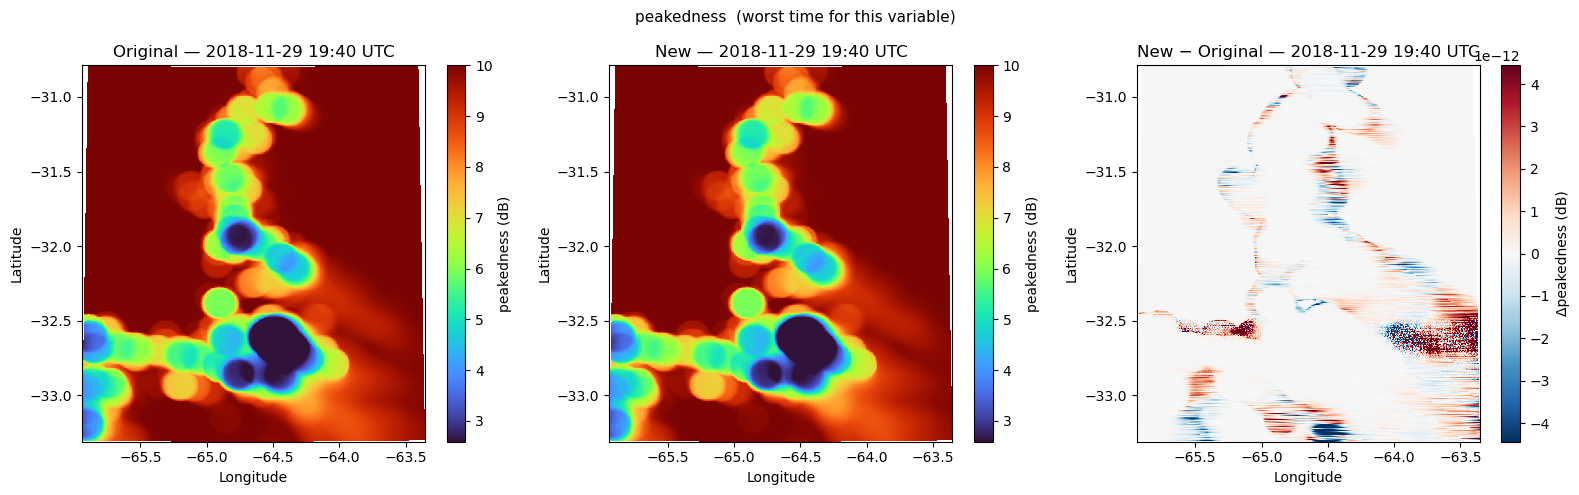

In [15]:
for vname, units in [("refl_bkg", "(dBZ)"), ("peakedness", "(dB)")]:
    ti = _worst_time_continuous(vname)
    print(f"\n{vname}  worst time: {timestamps[ti]}  (ti={ti})")
    _plot_3panel_continuous(vname, ti, cmap="turbo", units=units)

## 12  DIAGNOSTIC — Task 1: echotop_height_fast vs echotop_height

Compare the **actual filtered profile** seen by each function at the pixel with the
largest echotop10 difference: `jj=329, ii=102` in file `20181130.000000.nc`.

The notebook previously displayed the **raw** reflectivity (before `sfc_dz_min` filtering).
Here we load the same file through `get_composite_reflectivity_generic` so that
`dbz3d_filt` has the same NaN pattern as what was used when producing the cloudid outputs.

Steps:
1. Print raw vs filtered profile side-by-side to see which levels are masked
2. Step through `echotop_height_fast` level-by-level for this column
3. Call both functions on the full domain and compare with stored cloudid values

In [ ]:
import sys, importlib
sys.path.insert(0, str(Path("/ccsopen/home/zhe1feng1/program/PyFLEXTRKR-dev")))
import pyflextrkr.echotop_func as _echotop_mod
importlib.reload(_echotop_mod)   # pick up any local edits to echotop_func.py
from pyflextrkr.echotop_func import echotop_height, echotop_height_fast
from pyflextrkr.idcells_reflectivity import get_composite_reflectivity_generic

JJ_DIAG, II_DIAG   = 329, 102          # pixel in cloudid grid
DBZ_THRESH_DIAG     = 10.0
GAP_DIAG            = config['echotop_gap']

_fpath_diag = DIR_3D / "corlasso_cldhamsl_2018112900gefs09d3_base_M1.m1.20181130.000000.nc"
print(f"Source file exists: {_fpath_diag.exists()}")

# Build comp_dict: applies geolimits subsetting + sfc_dz_min filtering
comp_dict_diag = get_composite_reflectivity_generic(_fpath_diag, config)
dbz3d_filt_diag = comp_dict_diag['dbz3d_filt']
height_flt      = comp_dict_diag['height']

print(f"dbz3d_filt shape : {dbz3d_filt_diag.shape}")
print(f"height shape     : {height_flt.shape}")
print(f"default_sfc_height used: {config.get('default_sfc_height', 0)} m")
print(f"sfc_dz_min              : {config['sfc_dz_min']} m")
print(f"filter threshold (sfc+dz_min): {config.get('default_sfc_height', 0) + config['sfc_dz_min']} m")

# --- Load raw profile from file (no sfc filter) ---
_ds3 = xr.open_dataset(_fpath_diag)
_refl_raw = _ds3[REFL_VARNAME].values.squeeze()
_hmsl_raw = _ds3[HEIGHT_VARNAME].values.squeeze()
_mask_geo = (
    (_ds3[x_coordname].values.squeeze() >= lonmin) &
    (_ds3[x_coordname].values.squeeze() <= lonmax) &
    (_ds3[y_coordname].values.squeeze() >= latmin) &
    (_ds3[y_coordname].values.squeeze() <= latmax)
).squeeze()
_yg, _xg = np.where(_mask_geo)
_xmin_g, _xmax_g = int(_xg.min()), int(_xg.max())
_ymin_g, _ymax_g = int(_yg.min()), int(_yg.max())
_refl_raw_sub = _refl_raw[:, _ymin_g:_ymax_g+1, _xmin_g:_xmax_g+1]
_ds3.close()

# Extract height profile at target pixel
if height_flt.ndim == 3:
    hprof_diag = height_flt[:, JJ_DIAG, II_DIAG]
elif height_flt.ndim == 1:
    hprof_diag = height_flt
else:  # 4D
    hprof_diag = height_flt[0, :, JJ_DIAG, II_DIAG]

# Extract filtered and raw reflectivity profiles
dbz_da = dbz3d_filt_diag
if dbz_da.ndim == 4:
    prof_filt = dbz_da[0, :, JJ_DIAG, II_DIAG].values
else:
    prof_filt = dbz_da[:, JJ_DIAG, II_DIAG].values
prof_raw = _refl_raw_sub[:, JJ_DIAG, II_DIAG]

# Print side-by-side comparison
print(f"\n{'k':>3}  {'HAMSL(km)':>9}  {'raw_dBZ':>9}  {'filt_dBZ':>9}  note")
print("-" * 65)
for k in range(len(hprof_diag)):
    rv  = prof_raw[k]  if k < len(prof_raw)  else np.nan
    fv  = prof_filt[k] if k < len(prof_filt) else np.nan
    note = ""
    if np.isnan(fv) and not np.isnan(rv):
        note = "<-- masked by sfc_dz_min"
    elif not np.isnan(fv) and fv > DBZ_THRESH_DIAG:
        note = "<-- CLOUD (filt > 10 dBZ)"
    print(f"{k:>3}  {hprof_diag[k]/1e3:>9.3f}  {rv:>9.3f}  {fv:>9.3f}  {note}")

In [ ]:
# timestamps
pd.Series(timestamps)

In [ ]:
# ── Step-by-step trace of echotop_height_fast on the filtered profile ────
print(f"=== echotop_height_fast step trace — (jj={JJ_DIAG}, ii={II_DIAG}), gap={GAP_DIAG} ===\n")

cmask_col = np.array(prof_filt) > DBZ_THRESH_DIAG   # NaN>x = False → correct

last_cz = -1
pgap    = False
top_idx = -1

print(f"{'k':>3}  {'dBZ':>8}  {'cloud':>5}  {'last_cz':>7}  {'gap_tl':>6}  "
      f"{'pgap':>5}  {'in_1st':>6}  {'top_idx':>7}")
for k in range(len(cmask_col)):
    at_k = bool(cmask_col[k])
    seen = last_cz >= 0
    gtl  = seen and at_k and ((k - last_cz) > GAP_DIAG)
    if gtl:
        pgap = True
    in1st = at_k and not pgap
    if in1st:
        top_idx = k
        last_cz = k   # NEW: only advance while in first layer
    # Print row for cloud levels or the first 3 levels
    if at_k or k < 3:
        print(f"{k:>3}  {prof_filt[k]:>8.3f}  {str(at_k):>5}  {last_cz:>7}  "
              f"{str(gtl):>6}  {str(pgap):>5}  {str(in1st):>6}  {top_idx:>7}")

if top_idx >= 0:
    print(f"\n  -> first_layer_top_idx = {top_idx},  "
          f"height = {hprof_diag[top_idx]/1e3:.3f} km  (trace result)")
else:
    print("\n  -> No cloud found (trace result)")

# ── Compare with cloudid files + direct function calls ────────────────────
# timestamps_series = pd.Series(timestamps)
# ti_0000 = (timestamps_series - pd.Timestamp('2018-11-30 00:00:00')).abs()
# ti_0000 = int(np.argmin(np.abs(timestamps - pd.Timestamp("2018-11-30 00:00:00"))))
# target_time = np.datetime64('2018-11-30 00:00:00')
# 1. Ensure the timestamps array is actually in datetime64 format
timestamps_dt = timestamps.astype('datetime64[ns]')
# 2. Convert your target to the same format
target_time = np.datetime64('2018-11-30 00:00:00')
ti_0000 = int(np.argmin(np.abs(timestamps_dt - target_time)))
et_o_grid = data["echotop10"]["orig"][ti_0000]
et_n_grid = data["echotop10"]["new"][ti_0000]
print(f"\nFrom cloudid files (ti={ti_0000}, ts={timestamps[ti_0000]}):")
print(f"  echotop10 orig [{JJ_DIAG},{II_DIAG}] = {et_o_grid[JJ_DIAG,II_DIAG]/1e3:.3f} km")
print(f"  echotop10 new  [{JJ_DIAG},{II_DIAG}] = {et_n_grid[JJ_DIAG,II_DIAG]/1e3:.3f} km")

# Direct function calls on dbz3d_filt (should reproduce cloudid new output)
shape_2d_diag = (dbz3d_filt_diag.shape[-2], dbz3d_filt_diag.shape[-1])
et_orig_fn = echotop_height(dbz3d_filt_diag, height_flt, config['z_dimname'],
                            shape_2d_diag, DBZ_THRESH_DIAG, GAP_DIAG, 0)
et_fast_fn = echotop_height_fast(dbz3d_filt_diag, height_flt, config['z_dimname'],
                                 shape_2d_diag, DBZ_THRESH_DIAG, GAP_DIAG, 0)
print(f"\nDirect function calls on current dbz3d_filt (should match new cloudid if code unchanged):")
print(f"  echotop_height      [{JJ_DIAG},{II_DIAG}] = {et_orig_fn[JJ_DIAG,II_DIAG]/1e3:.3f} km")
print(f"  echotop_height_fast [{JJ_DIAG},{II_DIAG}] = {et_fast_fn[JJ_DIAG,II_DIAG]/1e3:.3f} km")
print(f"  Max |diff| over full domain: "
      f"{float(np.nanmax(np.abs(et_fast_fn.astype(float) - et_orig_fn.astype(float))))/1e3:.3f} km")

## 13  DIAGNOSTIC — Task 2: conv_mask extra cell at 2018-11-29 22:15

The new code identifies one extra cell near `lon=-64.2, lat=-32.3` that is absent in the original.

We run the idcell pipeline **step by step** at this timestamp to find which step introduces
the extra cell.  Four combinations are tested by mixing orig/new at the `dilate` and `expand` steps:

| dilate | expand | tag |
|--------|--------|-----|
| orig (ndimage + binary_dilation) | orig (expand_conv_core) | OO |
| edt  | orig  | EO — isolates effect of dilate method |
| orig | edt   | OE — isolates effect of expand method |
| edt  | edt   | EE — full new pipeline |

If the extra cell appears in EO but not OO → dilate method is the cause.
If it appears in OE but not OO → expand method is the cause.
If it appears in neither EO nor OE but in EE → interaction between the two.
If it already appears in OO → earlier divergence (e.g., convolve_method fft vs ndimage).

In [ ]:
import importlib
import pyflextrkr.steiner_func as _sf_mod
importlib.reload(_sf_mod)
from pyflextrkr.steiner_func import (
    mod_steiner_classification, make_dilation_step_func,
    expand_conv_core, expand_conv_core_edt,
)

# ── Target timestamp and pixel ────────────────────────────────────────────
TS_TGT  = pd.Timestamp("2018-11-29 22:15:00")
LAT_TGT, LON_TGT = -32.3, -64.2
ZOOM_LATMIN, ZOOM_LATMAX = -33.0, -31.5
ZOOM_LONMIN, ZOOM_LONMAX = -65.0, -63.5

# Find time index
ti_tgt = int(np.argmin(np.abs(timestamps - TS_TGT)))
print(f"Closest timestamp: {timestamps[ti_tgt]}  (ti={ti_tgt})")

# Find (j, i) in cloudid grid closest to target lat/lon
dist_sq = (lat2d - LAT_TGT)**2 + (lon2d - LON_TGT)**2
jj_tgt, ii_tgt = np.unravel_index(np.argmin(dist_sq), dist_sq.shape)
print(f"Target (jj, ii) = ({jj_tgt}, {ii_tgt})  "
      f"lat={lat2d[jj_tgt,ii_tgt]:.3f}  lon={lon2d[jj_tgt,ii_tgt]:.3f}")

# Print stored cloudid values at target pixel
cm_o_tgt = data["conv_mask"]["orig"][ti_tgt]
cm_n_tgt = data["conv_mask"]["new"][ti_tgt]
cmx_o_tgt = data["conv_mask_inflated"]["orig"][ti_tgt]
cmx_n_tgt = data["conv_mask_inflated"]["new"][ti_tgt]
print(f"\nFrom cloudid files at ({jj_tgt},{ii_tgt}):")
print(f"  conv_mask          orig={cm_o_tgt[jj_tgt,ii_tgt]}   new={cm_n_tgt[jj_tgt,ii_tgt]}")
print(f"  conv_mask_inflated orig={cmx_o_tgt[jj_tgt,ii_tgt]}  new={cmx_n_tgt[jj_tgt,ii_tgt]}")

# ── Load source 3D file and build comp_dict ───────────────────────────────
ts_str_3d = timestamps[ti_tgt].strftime("%Y%m%d.%H%M%S")
_fpath_tgt = DIR_3D / f"corlasso_cldhamsl_2018112900gefs09d3_base_M1.m1.{ts_str_3d}.nc"
print(f"\nSource 3D file: {_fpath_tgt.name}")
print(f"Exists: {_fpath_tgt.exists()}")

comp_tgt = get_composite_reflectivity_generic(_fpath_tgt, config)
refl_2d  = comp_tgt['refl']
mask_gv  = comp_tgt['mask_goodvalues']
dx, dy   = config['dx'], config['dy']

print(f"refl_2d shape: {refl_2d.shape}")
print(f"refl_2d at target ({jj_tgt},{ii_tgt}) = {refl_2d[jj_tgt,ii_tgt]:.3f} dBZ")

# ── Steiner dilation step-function parameters ─────────────────────────────
bkg_bin, conv_rad_bin = make_dilation_step_func(
    mindBZuse=config['mindBZuse'],
    dBZforMaxConvRadius=config['dBZforMaxConvRadius'],
    bkg_refl_increment=config['bkg_refl_increment'],
    conv_rad_increment=config['conv_rad_increment'],
    conv_rad_start=config['conv_rad_start'],
    maxConvRadius=config['maxConvRadius'],
)
types_steiner = {'NO_SURF_ECHO': 1, 'WEAK_ECHO': 2, 'STRATIFORM': 3, 'CONVECTIVE': 4}
radii_expand  = np.array(config['radii_expand'])
steiner_kw    = dict(
    types_steiner=types_steiner, refl=refl_2d, mask_goodvalues=mask_gv,
    dx=dx, dy=dy, bkg_rad=config['bkgrndRadius'] * 1000,
    minZdiff=config['minZdiff'], absConvThres=config['absConvThres'],
    truncZconvThres=config['truncZconvThres'], weakEchoThres=config['weakEchoThres'],
    bkg_bin=bkg_bin, conv_rad_bin=conv_rad_bin,
    min_corearea=config.get('min_corearea', 0),
    return_diag=True,
)

# ── Run Steiner classification: orig (ndimage, orig dilate) vs new (fft, edt dilate) ─
res_oo = mod_steiner_classification(**steiner_kw, convolve_method='ndimage', dilate_method='orig')
res_ee = mod_steiner_classification(**steiner_kw, convolve_method='fft',     dilate_method='edt')
# Mixed: fft conv + orig dilate (test if conv_method alone changes core)
res_eo = mod_steiner_classification(**steiner_kw, convolve_method='fft',     dilate_method='orig')

# ── Expand conv cores: all four combinations ──────────────────────────────
cex_oo, _ = expand_conv_core    (res_oo['score_dilate'], radii_expand, dx, dy, min_corenpix=0)
cex_oe, _ = expand_conv_core_edt(res_oo['score_dilate'], radii_expand, dx, dy, min_corenpix=0)
cex_eo, _ = expand_conv_core    (res_ee['score_dilate'], radii_expand, dx, dy, min_corenpix=0)
cex_ee, _ = expand_conv_core_edt(res_ee['score_dilate'], radii_expand, dx, dy, min_corenpix=0)

# ── Print scalar summary at target pixel ─────────────────────────────────
print(f"\n{'Variable':<25}  {'OO (orig)':>12}  {'EE (new)':>12}  {'EO':>12}")
print("-" * 65)
for key in ('refl_bkg', 'peakedness', 'score', 'score_dilate'):
    oo = float(res_oo[key][jj_tgt, ii_tgt])
    ee = float(res_ee[key][jj_tgt, ii_tgt])
    eo = float(res_eo[key][jj_tgt, ii_tgt])
    print(f"{key:<25}  {oo:>12.4f}  {ee:>12.4f}  {eo:>12.4f}")
print(f"\n{'conv_mask (OO=orig)':<25}  {cex_oo[jj_tgt,ii_tgt]:>12}  {cex_ee[jj_tgt,ii_tgt]:>12}")
print(f"{'conv_mask (OE=orig+edt_exp)':<25}  {cex_oe[jj_tgt,ii_tgt]:>12}")
print(f"{'conv_mask (EO=fft+orig_exp)':<25}  {cex_eo[jj_tgt,ii_tgt]:>12}")

In [ ]:
# ── Zoomed 2-panel plots for each pipeline step ───────────────────────────
# Build zoom slice on the cloudid grid
zm = ((lon2d >= ZOOM_LONMIN) & (lon2d <= ZOOM_LONMAX) &
      (lat2d >= ZOOM_LATMIN) & (lat2d <= ZOOM_LATMAX))
jz, iz = np.where(zm)
j0, j1 = int(jz.min()), int(jz.max())
i0, i1 = int(iz.min()), int(iz.max())
lon_z  = lon2d[j0:j1+1, i0:i1+1]
lat_z  = lat2d[j0:j1+1, i0:i1+1]

def _plot2_zoom(arr_o, arr_n, title, cmap="turbo", vmin=None, vmax=None, discrete=False):
    """Plot orig | new panels zoomed to the target region."""
    oz = arr_o[j0:j1+1, i0:i1+1].astype(float)
    nz = arr_n[j0:j1+1, i0:i1+1].astype(float)
    vals = np.concatenate([oz[np.isfinite(oz)], nz[np.isfinite(nz)]])
    if vmin is None:
        vmin = float(np.nanmin(vals)) if len(vals) > 0 else 0.0
    if vmax is None:
        vmax = float(np.nanmax(vals)) if len(vals) > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, arr, lbl in zip(axes, [oz, nz], ["Original (OO)", "New (EE)"]):
        if discrete:
            arr_disp = np.ma.masked_equal(arr, 0)
        else:
            arr_disp = arr
        im = ax.pcolormesh(lon_z, lat_z, arr_disp, cmap=cmap,
                           vmin=vmin, vmax=vmax, shading="auto")
        ax.plot(LON_TGT, LAT_TGT, 'kx', ms=12, mew=2.5, label="target")
        ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
        ax.set_title(lbl)
        plt.colorbar(im, ax=ax)
    plt.suptitle(f"{title}  —  {timestamps[ti_tgt].strftime('%Y-%m-%d %H:%M UTC')}", fontsize=11)
    plt.tight_layout()
    plt.show()

# 1. refl_bkg (differs only if convolve_method differs)
_plot2_zoom(res_oo['refl_bkg'], res_ee['refl_bkg'], "Step 1a: refl_bkg (OO vs EE)",
            cmap="RdYlBu_r")
# 2. peakedness
_plot2_zoom(res_oo['peakedness'], res_ee['peakedness'], "Step 1b: peakedness (OO vs EE)",
            cmap="RdYlBu_r")
# 3. conv core (score) — before dilation
_plot2_zoom(res_oo['score'], res_ee['score'], "Step 1c: conv score before dilation (OO vs EE)",
            cmap="Reds", vmin=0, vmax=1)
# 4. score_dilate (after dilation)
_plot2_zoom(res_oo['score_dilate'], res_ee['score_dilate'],
            "Step 1d: score_dilate (OO vs EE)", cmap="Reds", vmin=0, vmax=1)
# 5. conv_mask = core_expand (OO vs EE)
_plot2_zoom(cex_oo, cex_ee, "Step 2: conv_mask/core_expand (OO vs EE)",
            cmap="tab20", discrete=True)
# 6. OE (orig dilate, edt expand) vs OO — isolates expand method
_plot2_zoom(cex_oo, cex_oe, "Isolate expand: OO (orig+orig) vs OE (orig+edt)",
            cmap="tab20", discrete=True)
# 7. EO (fft/edt dilate, orig expand) vs OO — isolates dilate method
_plot2_zoom(cex_oo, cex_eo, "Isolate dilate: OO (orig+orig) vs EO (edt+orig)",
            cmap="tab20", discrete=True)

# 8. Difference maps: new>0 minus orig>0 (binary coverage)
for (arr_o, arr_n, tag) in [
    (cex_oo, cex_ee, "OO vs EE (full pipeline)"),
    (cex_oo, cex_oe, "OO vs OE (expand only)"),
    (cex_oo, cex_eo, "OO vs EO (dilate only)"),
]:
    diff_z = (arr_n[j0:j1+1, i0:i1+1] > 0).astype(np.int8) - \
             (arr_o[j0:j1+1, i0:i1+1] > 0).astype(np.int8)
    n_new_only  = int(np.sum(diff_z ==  1))
    n_orig_only = int(np.sum(diff_z == -1))
    print(f"{tag}: new-only pixels={n_new_only}, orig-only pixels={n_orig_only}")
    cmap_diff = mcolors.ListedColormap(["blue", "white", "red"])
    norm_diff = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap_diff.N)
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.pcolormesh(lon_z, lat_z, diff_z, cmap=cmap_diff, norm=norm_diff, shading="auto")
    cb = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1])
    cb.set_ticklabels(["Orig only", "Agree", "New only"])
    ax.plot(LON_TGT, LAT_TGT, 'kx', ms=12, mew=2.5, label="target")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"conv_mask coverage diff: {tag}\n"
                 f"new-only={n_new_only}, orig-only={n_orig_only}")
    plt.tight_layout(); plt.show()